# MUS Hypergraph Representation Benchmark

This notebook benchmarks six unsupervised hypergraph representations:

- **CIHI**: an edge-curvature histogram for each hypergraph.
- **HORC** (`HORC*`): an edge-curvature histogram for each hypergraph, using the best HORC configuration.
- **HGNN**: a learned graph embedding from the shared unsupervised HNN trainer.
- **HyperGCN**: a learned graph embedding from the same unsupervised trainer.
- **HGNN + node CIHI** and **HyperGCN + node CIHI**: curvature-informed variants that append each node's mean incident-edge CIHI to its initial features.

Every representation follows the same evaluation order: fit KPCA on all MUS hypergraphs, filter to the target periods, then run KMeans and calculate ARI/AMI.

## Conventions

- Labels are never used to train HGNN or HyperGCN.
- KPCA is fitted before period filtering for all six methods.
- KMeans uses three clusters, `random_state=42`, and `n_init=20`.
- `HORC*` is selected using the highest AMI on the evaluated subset. It is therefore an exploratory upper bound, not a strictly held-out model-selection result.
- Restart the kernel before running this notebook after changing files under `src/HNN`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from plotnine import *
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score
from tqdm.auto import tqdm

candidates = [Path.cwd(), Path.cwd() / "code", *Path.cwd().parents]
CODE_ROOT = next(p for p in candidates if (p / "src" / "__init__.py").is_file())
if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

from src import load_data
from src.HNN import HNNConfig, fit_hypergraph_embeddings
from src.hyg_cluster import cihi_histogram, horc_histogram, kpca

DATA_ROOT = CODE_ROOT.parent / "data"
ZISSOU1_CONTINUOUS = [
    "#3A9AB2", "#6FB2C1", "#91BAB6", "#A5C2A3", "#BDC881",
    "#DCCB4E", "#E3B710", "#E79805", "#EC7A05", "#EF5703", "#F11B00",
]

/Users/shiyi/.virtualenvs/lower-ricci/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Load MUS and edge curvatures

In [2]:
ds = load_data(dname="mus", data_folder=DATA_ROOT)
cihi = np.asarray([np.nan if x is None else x for x in ds.get_cihi()], dtype=float)
hfrc = np.asarray([np.nan if x is None else x for x in ds.get_hfrc()], dtype=float)
horc = pd.DataFrame(ds.get_horc(all_configurations=True), dtype=float)
horc_metrics = [column for column in horc if column == "horc" or column.startswith("horc_")]

assert len(cihi) == len(hfrc) == len(horc) == len(ds.hyperedges)
print(ds)
print(f"HORC configurations: {len(horc_metrics)}")

HypergraphDataset(num_hyperedges=496792, num_nodes=61, num_hypergraphs=1944, node_labels=no, edge_labels=no, hypergraph_labels=yes, max_dv=89857, max_de=12, perc_de2=12.3%)
Unique Hypergraph labels (14): ['bach', 'beethoven', 'chopin', 'handel', 'haydn', 'joplin', 'monteverdi', 'mozart', 'palestrina', 'schubert']
HORC configurations: 36


## Curvature correlation

This edge-level analysis is separate from the hypergraph-level representation benchmark below.

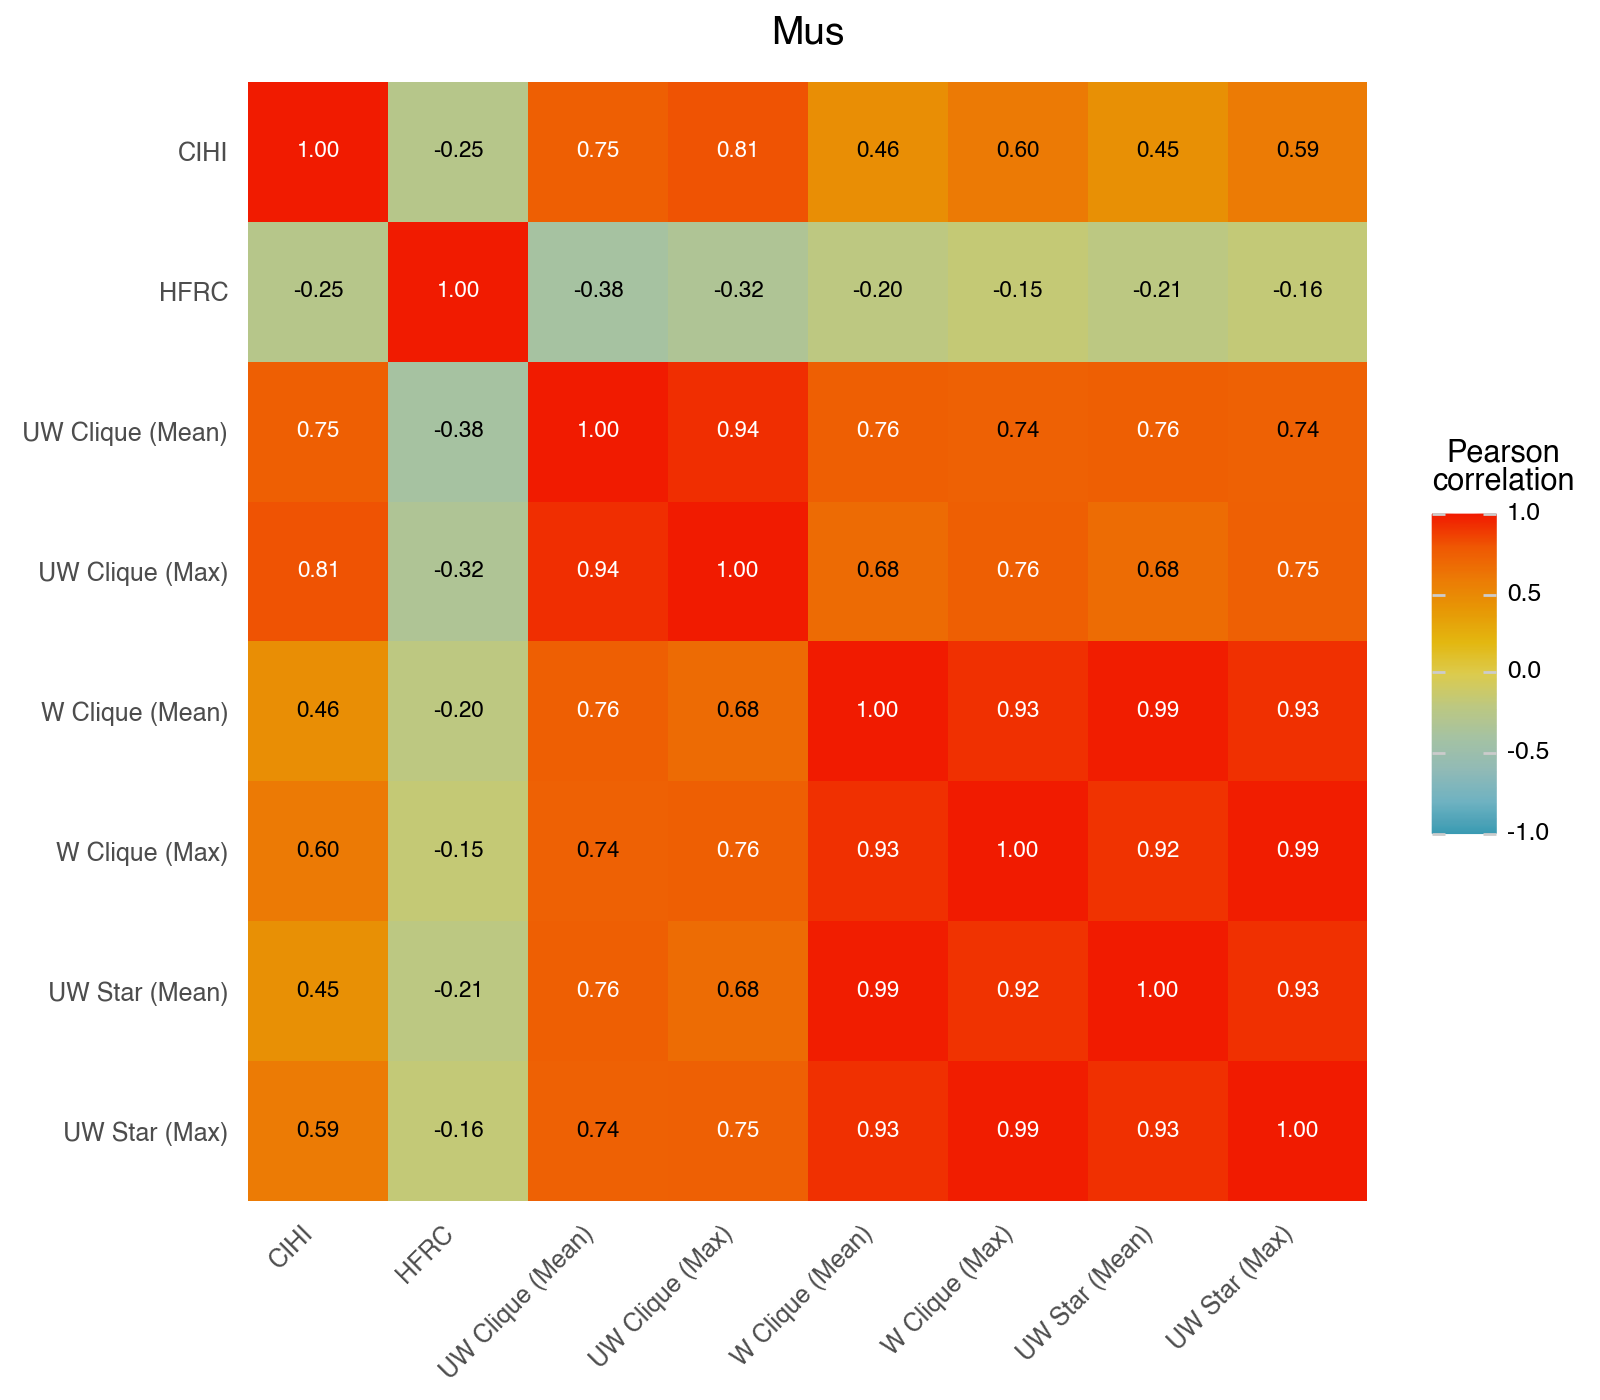

In [21]:
corr_metrics = [column for column in horc_metrics if column == "horc" or column.endswith("_a0p0")]
corr_labels = {
    "cihi": "CIHI",
    "hfrc": "HFRC",
    "horc": "UW Clique (Mean)",
    "horc_uw_clique_max_a0p0": "UW Clique (Max)",
    "horc_w_clique_mean_a0p0": "W Clique (Mean)",
    "horc_w_clique_max_a0p0": "W Clique (Max)",
    "horc_uw_star_mean_a0p0": "UW Star (Mean)",
    "horc_uw_star_max_a0p0": "UW Star (Max)",
}
corr_data = pd.concat([pd.DataFrame({"cihi": cihi, "hfrc": hfrc}), horc[corr_metrics]], axis=1)
corr = corr_data.corr(method="pearson").rename(index=corr_labels, columns=corr_labels)
corr_long = pd.DataFrame(
    [(row, column, corr.loc[row, column]) for row in corr.index for column in corr.columns],
    columns=["metric_y", "metric_x", "correlation"],
)
corr_long["label"] = corr_long["correlation"].map(lambda value: f"{value:.2f}")
corr_long["text_color"] = np.where(corr_long["correlation"].abs() > 0.75, "white", "black")
corr_order = list(corr.columns)
corr_long["metric_x"] = pd.Categorical(corr_long["metric_x"], corr_order, ordered=True)
corr_long["metric_y"] = pd.Categorical(corr_long["metric_y"], corr_order[::-1], ordered=True)

p_corr = (
    ggplot(corr_long, aes("metric_x", "metric_y", fill="correlation"))
    + geom_tile()
    + geom_text(aes(label="label", color="text_color"), size=8)
    + scale_fill_gradientn(colors=ZISSOU1_CONTINUOUS, limits=(-1, 1), name="Pearson\ncorrelation")
    + scale_color_identity()
    + coord_equal()
    + labs(title=r"Mus", x="", y="")
    + theme_minimal()
    + theme(
        figure_size=(8, 7),
        plot_title=element_text(size=14, ha="center"),
        axis_text_x=element_text(rotation=45, ha="right", size=9),
        axis_text_y=element_text(size=9),
        panel_grid=element_blank(),
    )
)
p_corr

In [22]:
p_corr.save(
    CODE_ROOT / "mus" / "mus_corr.pdf",
    width=6,
    height=5,
    units="in",
    verbose=False,
)

## Evaluation labels and shared helpers

In [4]:
period_groups = {
    "Renaissance": ["monteverdi", "trecento"],
    "Baroque": ["bach", "handel"],
    "Later": [
        "haydn", "mozart", "beethoven", "schumann", "schubert",
        "chopin", "verdi", "weber", "joplin",
    ],
}
period_colors = dict(zip(
    period_groups,
    [ZISSOU1_CONTINUOUS[1], ZISSOU1_CONTINUOUS[4], ZISSOU1_CONTINUOUS[7]],
))
composer_to_period = {
    composer: period
    for period, composers in period_groups.items()
    for composer in composers
}
composer_labels = np.asarray(ds.hypergraph_labels)
period_mask = np.isin(composer_labels, list(composer_to_period))
selected_composers = composer_labels[period_mask]
true_periods = np.asarray([composer_to_period[composer] for composer in selected_composers])
pd.Series(true_periods, name="period").value_counts()

period
Baroque        411
Renaissance    151
Later           64
Name: count, dtype: int64

In [5]:
edge_hg_idx = np.asarray(ds.hypergraph_idx)
starts = np.r_[0, np.flatnonzero(edge_hg_idx[1:] != edge_hg_idx[:-1]) + 1]
stops = np.r_[starts[1:], len(edge_hg_idx)]
hg_order = edge_hg_idx[starts]

assert len(hg_order) == len(composer_labels) == len(period_mask)

def curvature_representation(values, histogram_function):
    values = np.asarray(values, dtype=float)
    representation = histogram_function([
        values[start:stop] for start, stop in zip(starts, stops)
    ])
    if not np.isfinite(representation).all():
        raise ValueError("Curvature histogram contains non-finite values.")
    return representation

def evaluate_kmeans(embedding, labels):
    predicted = KMeans(
        n_clusters=3, random_state=42, n_init=20
    ).fit_predict(embedding)
    scores = {
        "ARI": adjusted_rand_score(labels, predicted),
        "AMI": adjusted_mutual_info_score(labels, predicted),
    }
    return scores, predicted

## CIHI and HORC histogram representations

In [6]:
cihi_representation = curvature_representation(cihi, cihi_histogram)
horc_representations = {
    metric: curvature_representation(horc[metric].to_numpy(), horc_histogram)
    for metric in tqdm(horc_metrics, desc="HORC histograms")
}

print("CIHI representation:", cihi_representation.shape)
print("HORC representations:", len(horc_representations))

HORC histograms: 100%|██████████| 36/36 [00:01<00:00, 20.99it/s]

CIHI representation: (1944, 40)
HORC representations: 36


## Select HORC*

Each HORC configuration independently follows representation → KPCA on all hypergraphs → period filtering → KMeans.

In [7]:
horc_kpca_all = {
    metric: kpca(representation, 2)
    for metric, representation in tqdm(horc_representations.items(), desc="HORC KPCA")
}
horc_records = []
for metric, embedding_all in horc_kpca_all.items():
    scores, _ = evaluate_kmeans(embedding_all[period_mask], true_periods)
    horc_records.append({"configuration": metric, **scores})

horc_configuration_results = (
    pd.DataFrame(horc_records)
    .sort_values(["AMI", "ARI"], ascending=False)
    .reset_index(drop=True)
)
best_horc = horc_configuration_results.iloc[0]
best_horc_metric = str(best_horc["configuration"])
horc_configuration_results.head(10)

HORC KPCA: 100%|██████████| 36/36 [00:56<00:00,  1.56s/it]


,configuration,ARI,AMI
0,horc_w_clique_max_a0p3,0.301885,0.329066
1,horc_uw_clique_max_a0p2,0.303591,0.299733
2,horc_w_clique_max_a0p5,0.282884,0.299168
3,horc_w_clique_max_a0p4,0.284567,0.298665
4,horc_uw_clique_max_a0p3,0.297822,0.292363
5,horc_uw_star_max_a0p5,0.280823,0.290637
6,horc_uw_star_max_a0p3,0.274963,0.283120
7,horc_uw_clique_max_a0p5,0.282629,0.279662
8,horc_w_clique_max_a0p2,0.270259,0.277303
9,horc_uw_star_max_a0p4,0.271987,0.277047


## Learn HGNN and HyperGCN representations

The learned embeddings are cached because training is substantially more expensive than KPCA. Set `RETRAIN_HNN=True` after changing model or training settings.

In [8]:
HNN_RANDOM_STATE = 42
HNN_METHODS = ("hgnn", "hypergcn")
hnn_config = HNNConfig(
    embedding_dim=64,
    hidden_dim=128,
    num_layers=2,
    epochs=50,
    batch_size=32,
)
HNN_CACHE = CODE_ROOT / "mus" / (
    f"hnn_embeddings_d{hnn_config.embedding_dim}_h{hnn_config.hidden_dim}_"
    f"l{hnn_config.num_layers}_e{hnn_config.epochs}_b{hnn_config.batch_size}_"
    f"seed{HNN_RANDOM_STATE}.npz"
)
RETRAIN_HNN = False

if HNN_CACHE.exists() and not RETRAIN_HNN:
    with np.load(HNN_CACHE, allow_pickle=False) as cached:
        cached_hg_order = cached["hypergraph_ids"]
        hnn_representations = {method: cached[method] for method in HNN_METHODS}
    if not np.array_equal(cached_hg_order, hg_order):
        raise ValueError("Cached HNN hypergraph order does not match the dataset.")
    print(f"Loaded HNN embeddings from {HNN_CACHE}")
else:
    hnn_results = {}
    for method in HNN_METHODS:
        print(f"\nTraining {method.upper()}")
        hnn_results[method] = fit_hypergraph_embeddings(
            ds,
            method=method,
            config=hnn_config,
            feature_mode="auto",
            device="cpu",
            random_state=HNN_RANDOM_STATE,
        )
        if not np.array_equal(np.asarray(hnn_results[method].hypergraph_ids), hg_order):
            raise ValueError(f"{method} hypergraph order does not match MUS.")
    hnn_representations = {
        method: result.embeddings for method, result in hnn_results.items()
    }
    np.savez_compressed(
        HNN_CACHE,
        hypergraph_ids=hg_order,
        **hnn_representations,
    )
    print(f"Saved HNN embeddings to {HNN_CACHE}")

for method, representation in hnn_representations.items():
    print(method, representation.shape)

Loaded HNN embeddings from /Users/shiyi/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Research/CIHI/Lower Ricci Curvature for Hypergraph/code/mus/hnn_embeddings_d64_h128_l2_e50_b32_seed42.npz
hgnn (1944, 64)
hypergcn (1944, 64)


## CIHI-informed node initialization

For each node $v$, define $c_v=|E_v^{\mathrm{fin}}|^{-1}\sum_{e\in E_v^{\mathrm{fin}}}c_e$, where $E_v^{\mathrm{fin}}$ contains incident hyperedges with finite CIHI. Nodes without any finite incident CIHI are assigned the global mean. The globally standardized $c_v$ is appended to the original identity-plus-degree feature, producing 63-dimensional initial node features.

In [9]:
CIHI_NODE_CACHE = CODE_ROOT / "mus" / (
    f"hnn_node_cihi_d{hnn_config.embedding_dim}_h{hnn_config.hidden_dim}_"
    f"l{hnn_config.num_layers}_e{hnn_config.epochs}_b{hnn_config.batch_size}_"
    f"seed{HNN_RANDOM_STATE}.npz"
)
RETRAIN_CIHI_NODE_HNN = False

if CIHI_NODE_CACHE.exists() and not RETRAIN_CIHI_NODE_HNN:
    with np.load(CIHI_NODE_CACHE, allow_pickle=False) as cached:
        cached_hg_order = cached["hypergraph_ids"]
        cihi_node_representations = {method: cached[method] for method in HNN_METHODS}
    if not np.array_equal(cached_hg_order, hg_order):
        raise ValueError("Cached CIHI-node hypergraph order does not match MUS.")
    print(f"Loaded CIHI-node embeddings from {CIHI_NODE_CACHE}")
else:
    cihi_node_results = {}
    for method in HNN_METHODS:
        print(f"\nTraining {method.upper()} + node CIHI")
        cihi_node_results[method] = fit_hypergraph_embeddings(
            ds,
            method=method,
            config=hnn_config,
            feature_mode="auto",
            hyperedge_curvatures=cihi,
            standardize_node_curvature=True,
            device="cpu",
            random_state=HNN_RANDOM_STATE,
        )
        if not np.array_equal(np.asarray(cihi_node_results[method].hypergraph_ids), hg_order):
            raise ValueError(f"{method} + node CIHI order does not match MUS.")
    cihi_node_representations = {
        method: result.embeddings for method, result in cihi_node_results.items()
    }
    np.savez_compressed(
        CIHI_NODE_CACHE,
        hypergraph_ids=hg_order,
        **cihi_node_representations,
    )
    print(f"Saved CIHI-node embeddings to {CIHI_NODE_CACHE}")

for method, representation in cihi_node_representations.items():
    print(f"{method} + node CIHI", representation.shape)


Training HGNN + node CIHI
Epoch 001/50: loss=2.272709
Epoch 005/50: loss=1.223610
Epoch 010/50: loss=1.047245
Epoch 015/50: loss=0.940584
Epoch 020/50: loss=0.913244
Epoch 025/50: loss=0.865422
Epoch 030/50: loss=0.851708
Epoch 035/50: loss=0.814947
Epoch 040/50: loss=0.799331
Epoch 045/50: loss=0.827832
Epoch 050/50: loss=0.818295

Training HYPERGCN + node CIHI
HyperGCN preprocessing 1/1944
HyperGCN preprocessing 250/1944
HyperGCN preprocessing 500/1944
HyperGCN preprocessing 750/1944
HyperGCN preprocessing 1000/1944
HyperGCN preprocessing 1250/1944
HyperGCN preprocessing 1500/1944
HyperGCN preprocessing 1750/1944
HyperGCN preprocessing 1944/1944
Epoch 001/50: loss=2.424801
Epoch 005/50: loss=1.236000
Epoch 010/50: loss=1.029943
Epoch 015/50: loss=0.926266
Epoch 020/50: loss=0.859439
Epoch 025/50: loss=0.780067
Epoch 030/50: loss=0.756617
Epoch 035/50: loss=0.724518
Epoch 040/50: loss=0.708076
Epoch 045/50: loss=0.713521
Epoch 050/50: loss=0.684906
Saved CIHI-node embeddings to /User

## Shared KPCA and KMeans benchmark

In [10]:
kpca_embeddings_all = {
    "CIHI": kpca(cihi_representation, 2),
    "HORC*": horc_kpca_all[best_horc_metric],
    "HGNN": kpca(hnn_representations["hgnn"], 2),
    "HyperGCN": kpca(hnn_representations["hypergcn"], 2),
    "HGNN + node CIHI": kpca(cihi_node_representations["hgnn"], 2),
    "HyperGCN + node CIHI": kpca(cihi_node_representations["hypergcn"], 2),
}

method_order = [
    "CIHI", "HORC*", "HGNN", "HyperGCN",
    "HGNN + node CIHI", "HyperGCN + node CIHI",
]
method_configurations = {
    "CIHI": "CIHI histogram",
    "HORC*": best_horc_metric,
    "HGNN": "identity + degree",
    "HyperGCN": "identity + degree",
    "HGNN + node CIHI": "identity + degree + mean incident CIHI",
    "HyperGCN + node CIHI": "identity + degree + mean incident CIHI",
}
selected_embeddings = {}
predictions = {}
benchmark_records = []

for method in method_order:
    selected = kpca_embeddings_all[method][period_mask]
    scores, predicted = evaluate_kmeans(selected, true_periods)
    selected_embeddings[method] = selected
    predictions[method] = predicted
    benchmark_records.append({
        "method": method,
        "configuration": method_configurations[method],
        **scores,
    })

benchmark_summary = pd.DataFrame(benchmark_records)
benchmark_summary["method"] = pd.Categorical(
    benchmark_summary["method"], method_order, ordered=True
)
benchmark_summary

,method,configuration,ARI,AMI
0,CIHI,CIHI histogram,0.415412,0.355741
1,HORC*,horc_w_clique_max_a0p3,0.301885,0.329066
2,HGNN,identity + degree,0.247300,0.291164
3,HyperGCN,identity + degree,0.191684,0.257567
4,HGNN + node CIHI,identity + degree + mean incident CIHI,0.276838,0.322890
5,HyperGCN + node CIHI,identity + degree + mean incident CIHI,0.552570,0.426528


## KPCA embedding comparison

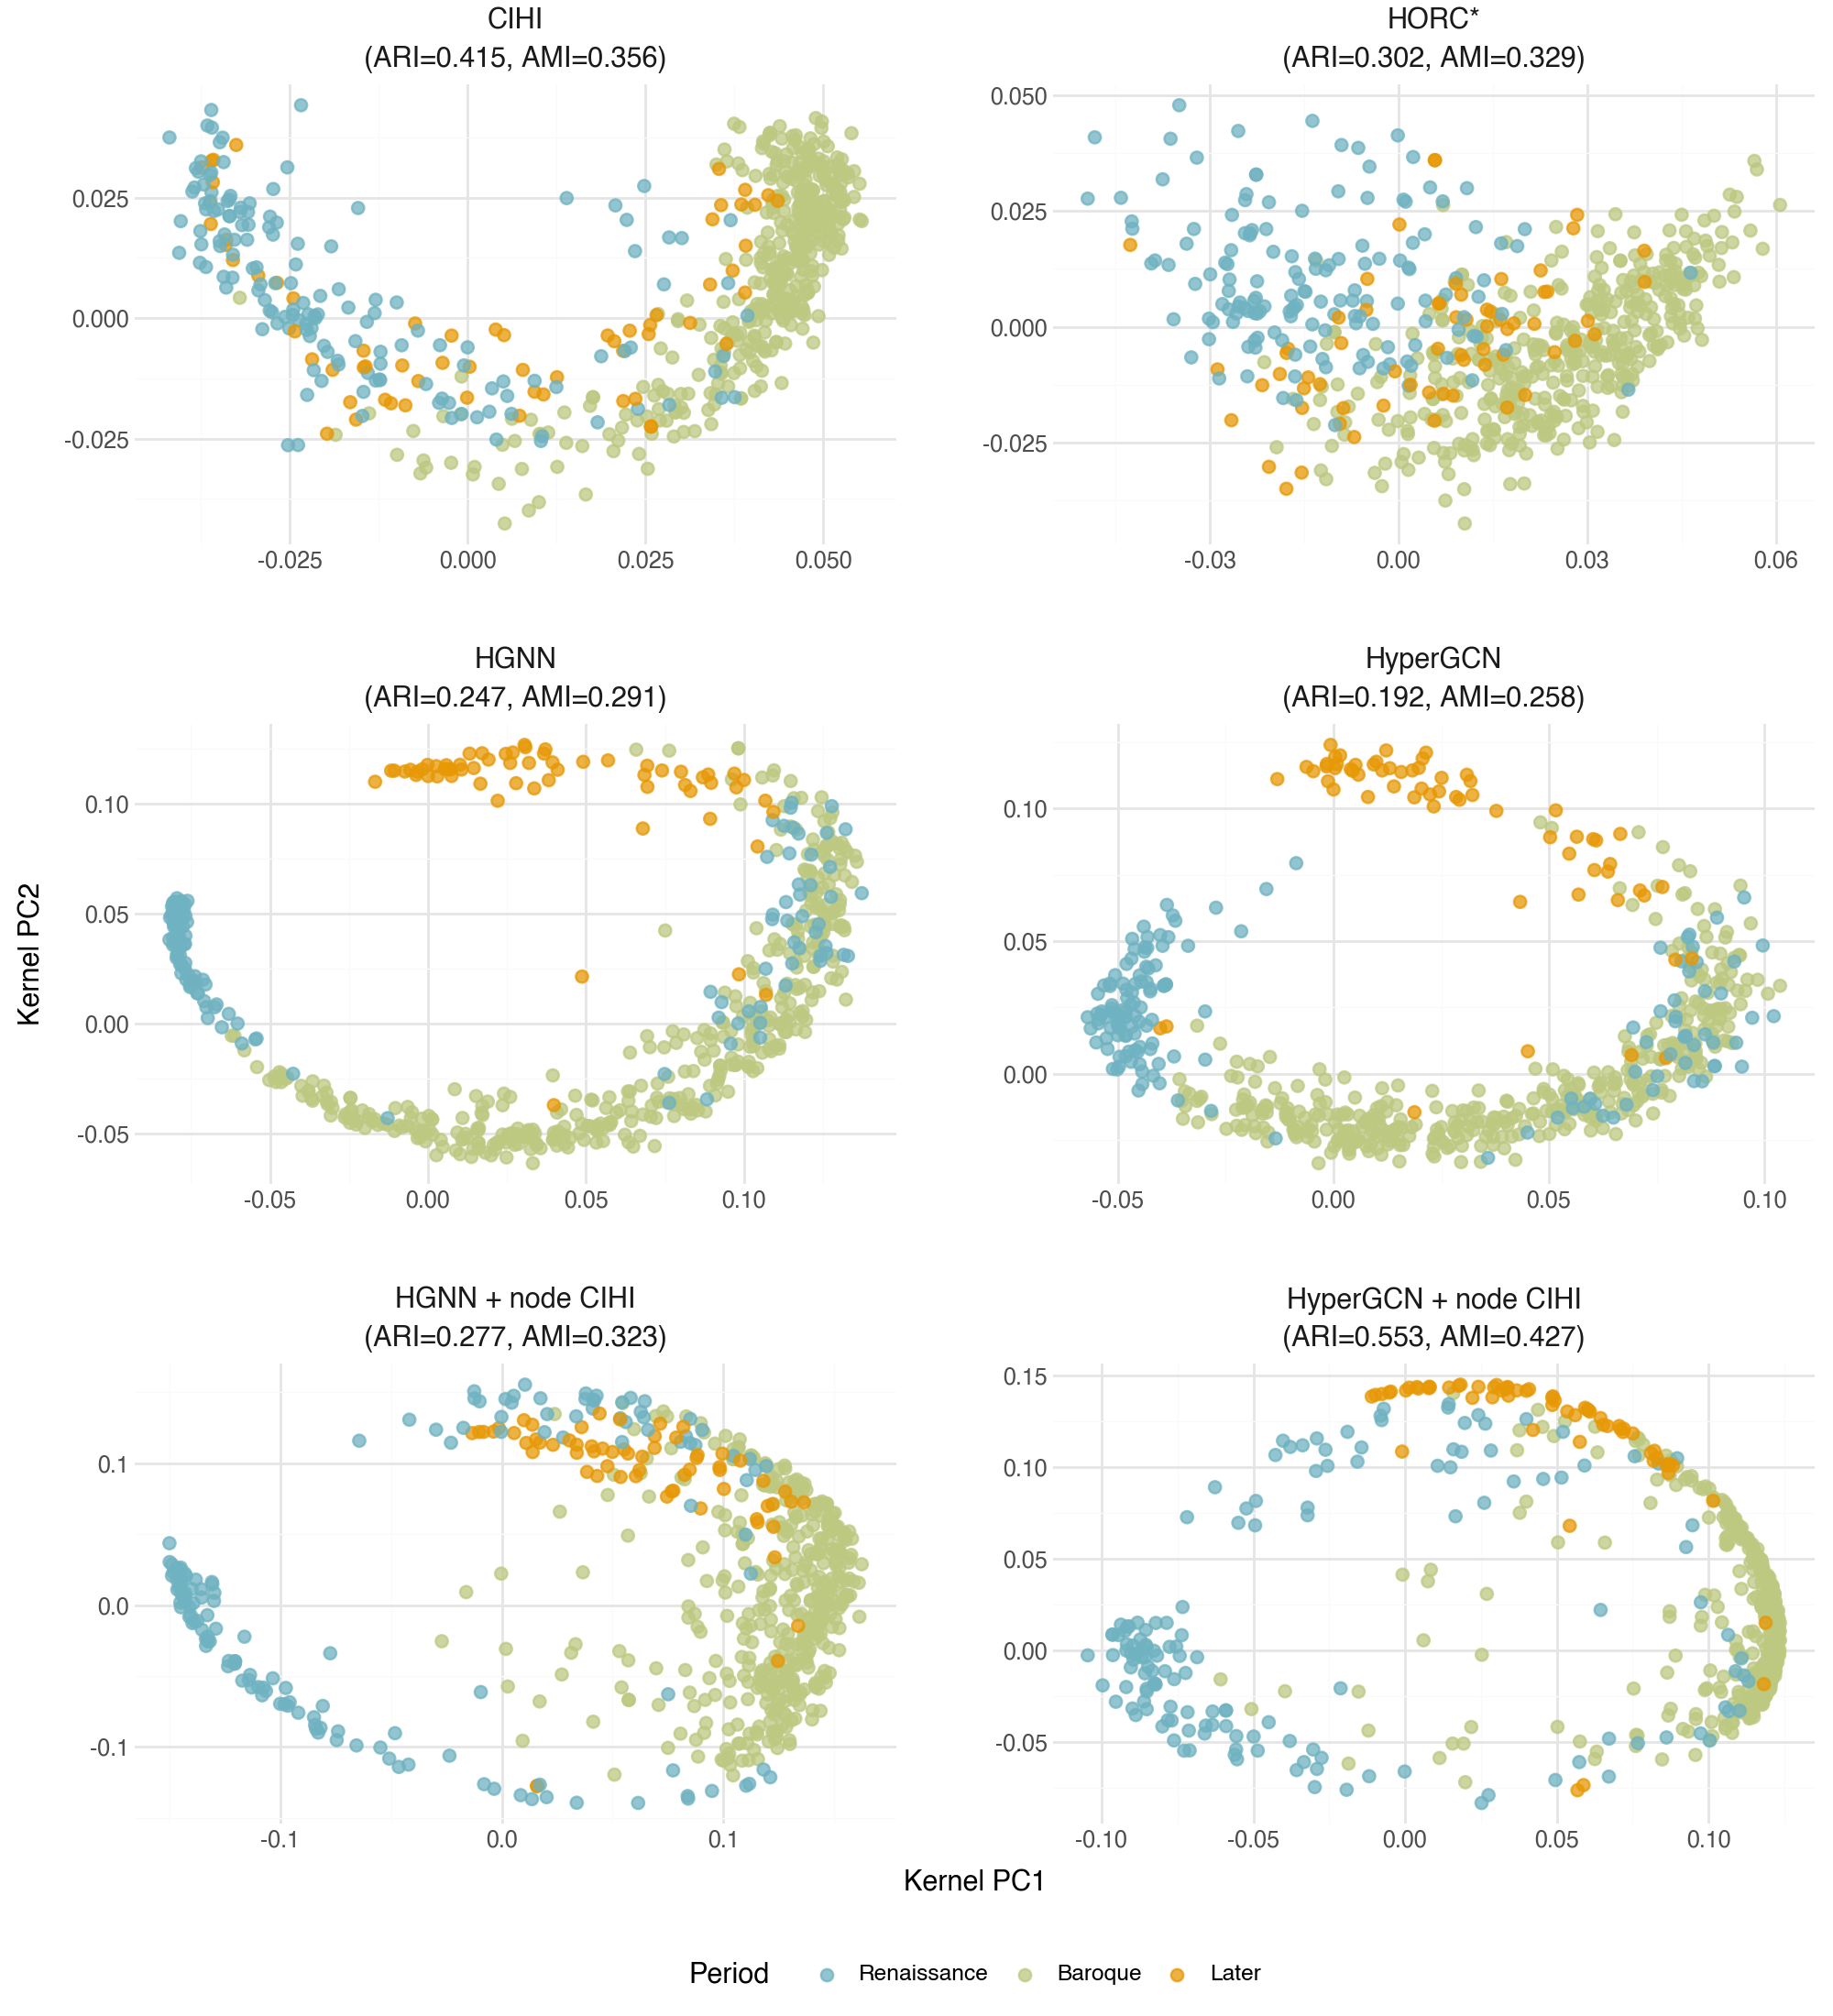

In [11]:
score_lookup = benchmark_summary.set_index("method")[["ARI", "AMI"]].to_dict("index")
facet_titles = {
    method: (
        f"{method}\n(ARI={score_lookup[method]['ARI']:.3f}, "
        f"AMI={score_lookup[method]['AMI']:.3f})"
    )
    for method in method_order
}

embedding_plot_data = pd.concat([
    pd.DataFrame({
        "Kernel PC1": selected_embeddings[method][:, 0],
        "Kernel PC2": selected_embeddings[method][:, 1],
        "method": facet_titles[method],
        "period": true_periods,
        "composer": selected_composers,
    })
    for method in method_order
], ignore_index=True)
embedding_plot_data["method"] = pd.Categorical(
    embedding_plot_data["method"],
    [facet_titles[method] for method in method_order],
    ordered=True,
)
embedding_plot_data["period"] = pd.Categorical(
    embedding_plot_data["period"], list(period_groups), ordered=True
)

p_embeddings = (
    ggplot(embedding_plot_data, aes("Kernel PC1", "Kernel PC2", color="period"))
    + geom_point(size=2.2, alpha=0.75)
    + facet_wrap("method", ncol=2, scales="free")
    + scale_color_manual(values=period_colors)
    + labs(color="Period")
    + theme_minimal()
    + theme(
        figure_size=(10, 11),
        legend_position="bottom",
        panel_spacing_x=0.05,
        panel_spacing_y=0.05,
        strip_text=element_text(size=11, ha="center"),
        axis_title=element_text(size=11),
        axis_text=element_text(size=9),
    )
)
p_embeddings

In [14]:
p_embeddings.save(
    CODE_ROOT / "mus" / "mus_embeddings.pdf",
    width=10,
    height=8,
    units="in",
    verbose=False,
)

## ARI and AMI comparison

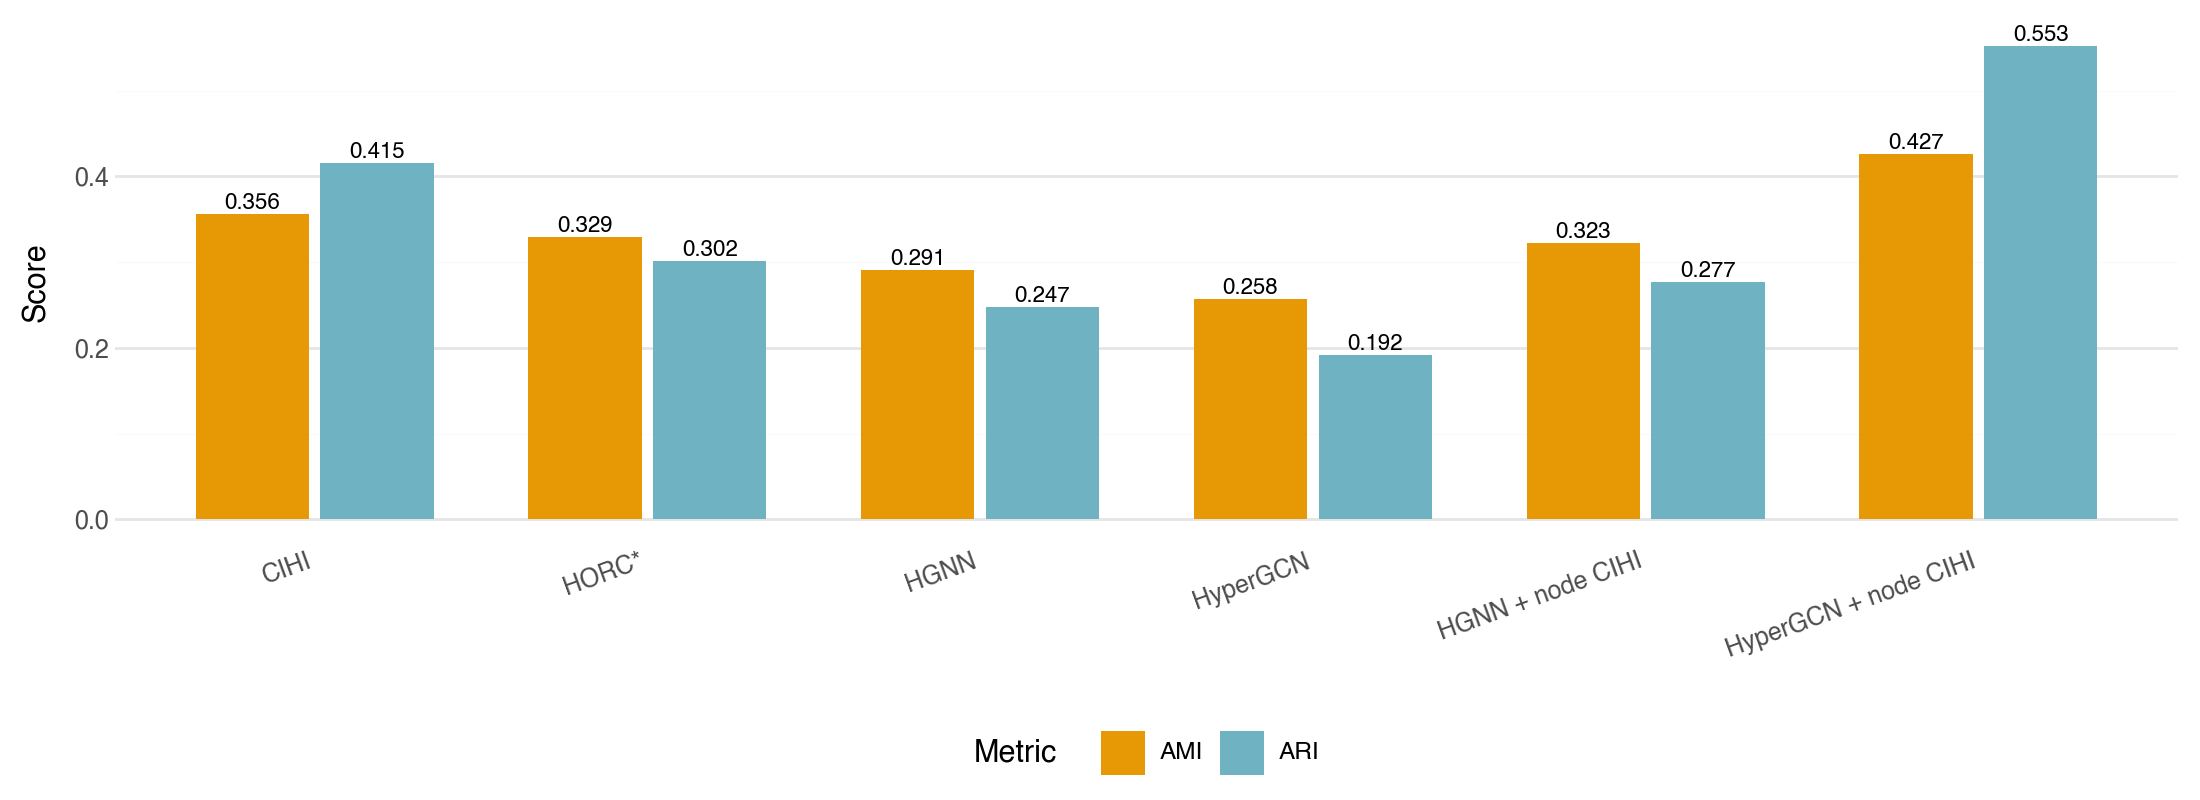

In [13]:
score_plot_data = benchmark_summary.melt(
    id_vars=["method", "configuration"],
    value_vars=["ARI", "AMI"],
    var_name="score_type",
    value_name="score",
)
score_plot_data["label"] = score_plot_data["score"].map(lambda value: f"{value:.3f}")

p_scores = (
    ggplot(score_plot_data, aes("method", "score", fill="score_type"))
    + geom_col(position=position_dodge(width=0.75), width=0.68)
    + geom_text(
        aes(label="label"),
        position=position_dodge(width=0.75),
        va="bottom",
        size=8,
    )
    + scale_fill_manual(values={"ARI": ZISSOU1_CONTINUOUS[1], "AMI": ZISSOU1_CONTINUOUS[7]})
    + labs(x="", y="Score", fill="Metric")
    + theme_minimal()
    + theme(
        figure_size=(11, 4),
        legend_position="bottom",
        axis_text_x=element_text(rotation=20, ha="right", size=9),
        axis_text_y=element_text(size=9),
        axis_title_y=element_text(size=11),
        panel_grid_major_x=element_blank(),
    )
)
p_scores